In [1]:
import numpy as np
import dask , dask.distributed
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cmocean.cm as cmo
import warnings
warnings.simplefilter('ignore')
import dask_jobqueue
from astropy.convolution import Box2DKernel, convolve
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import matplotlib.colors as colors
import pandas as pd
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable


# Custom functions (assumed in your local directory)
from fix_grid import fix_grid 
from useful_calculations import weighted_means

In [8]:
ds=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/mean_std_control_noice.nc', chunks='auto')

In [3]:
jin=xr.open_dataset('GOBAI-O2-v2.3-Flux-Adjusted.nc')

In [30]:
fay=xr.open_dataset('SeaFlux_v2021.04_fgco2_all_winds_products.nc')

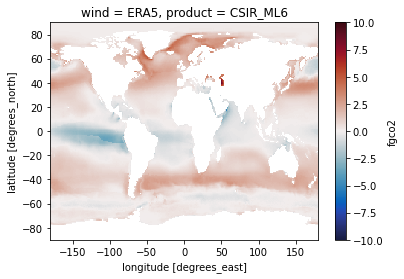

In [43]:
(fay.fgco2.sel(wind='ERA5', product='CSIR_ML6').mean(dim='time')*-1).plot(vmin=-10,vmax=10, cmap=cmo.balance)

In [61]:
jin.fgo2_mean

<xarray.DataArray 'fgo2_mean' (time: 252, lat: 145, lon: 360)>
array([[[-1.546419e-07, -1.678029e-07, ..., -1.563367e-07, -1.800176e-07],
        [ 6.127523e-08,  1.363605e-08, ...,  1.617922e-07,  1.041743e-07],
        ...,
        [          nan,           nan, ...,           nan,           nan],
        [          nan,           nan, ...,           nan,           nan]],

       [[-2.400534e-08, -6.594551e-08, ...,  8.994770e-08,  2.191553e-08],
        [ 5.257032e-08,  2.987504e-08, ...,  1.477859e-07,  8.912875e-08],
        ...,
        [          nan,           nan, ...,           nan,           nan],
        [          nan,           nan, ...,           nan,           nan]],

       ...,

       [[-2.508140e-07, -3.183704e-07, ..., -3.239889e-07, -2.460868e-07],
        [-3.312595e-07, -2.735679e-07, ..., -3.717215e-07, -3.461052e-07],
        ...,
        [          nan,           nan, ...,           nan,           nan],
        [          nan,           nan, ...,           nan,           nan]],

       [[-1.584144e-07, -1.670690e-07, ..., -2.054418e-07, -2.144211e-07],
        [-2.977921e-07, -3.034314e-07, ..., -3.087834e-07, -3.116400e-07],
        ...,
        [          nan,           nan, ...,           nan,           nan],
        [          nan,           nan, ...,           nan,           nan]]],
      dtype=float32)
Coordinates:
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 -64.5 -63.5 -62.5 -61.5 -60.5 ... 76.5 77.5 78.5 79.5
  * time     (time) datetime64[ns] 2004-01-15 2004-02-15 ... 2024-12-15
Attributes:
    units:      mol/m2/s
    long_name:  Flux Average

In [46]:
fay.fgco2.wind

<xarray.DataArray 'wind' (wind: 5)>
array(['CCMP2', 'ERA5', 'JRA55', 'NCEP1', 'NCEP2'], dtype=object)
Coordinates:
  * wind     (wind) object 'CCMP2' 'ERA5' 'JRA55' 'NCEP1' 'NCEP2'

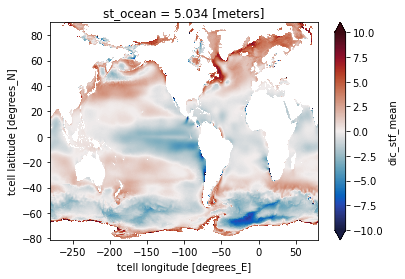

In [41]:
ds.dic_stf_mean.plot(vmin=-10, vmax=10, cmap=cmo.balance)

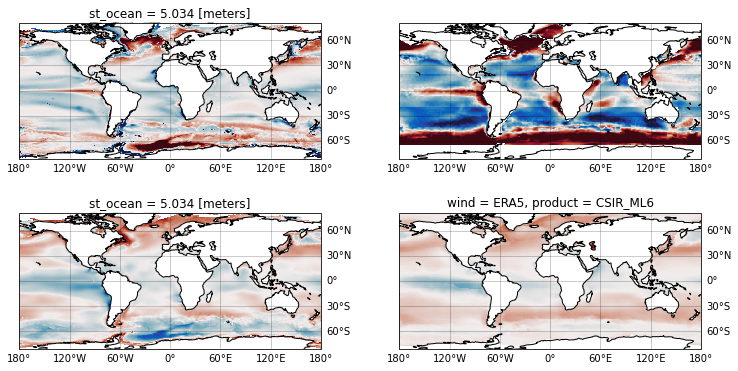

In [62]:
fig = plt.figure(figsize=(13,6),layout='compressed')
gs = gridspec.GridSpec(2, 2, wspace=.1, hspace=.4)

ax1 = fig.add_subplot(gs[0],projection=ccrs.PlateCarree(central_longitude=0))
ax2 = fig.add_subplot(gs[1],projection=ccrs.PlateCarree(central_longitude=0))
ax3 = fig.add_subplot(gs[2],projection=ccrs.PlateCarree(central_longitude=0))
ax4 = fig.add_subplot(gs[3],projection=ccrs.PlateCarree(central_longitude=0))

#ax3 = fig.add_subplot(gs[3],projection=ccrs.PlateCarree(central_longitude=0))
#ax13 = fig.add_subplot(gs[9],projection=ccrs.PlateCarree(central_longitude=0))
#ax14 = fig.add_subplot(gs[10],projection=ccrs.PlateCarree(central_longitude=0))
#ax15 = fig.add_subplot(gs[15],projection=ccrs.PlateCarree(central_longitude=0))
for i in [ax1,ax2,ax3,ax4]:    
    i.set_extent([-180, 180, -81.108635, 81.108635], crs=ccrs.PlateCarree())

#
#
im1=ds.o2_stf_mean.plot(ax=ax1, x='geolon_t', y='geolat_t',vmin=-15, vmax=15, cmap=cmo.balance, transform=ccrs.PlateCarree(), add_colorbar=False)#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})
#ax5=fig.add_subplot(gs[2])
#cbar1=plt.colorbar(im1, cax=ax5, orientation='horizontal',label= "[mol/m^2*yr]",extend='both')

im2=(jin.fgo2_mean.mean(dim='time')*-60*60*24*365).plot(ax=ax2,vmin=-15, vmax=15, cmap=cmo.balance, transform=ccrs.PlateCarree(), add_colorbar=False)#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})
#ax6=fig.add_subplot(gs[3])
#cbar2=plt.colorbar(im2, cax=ax6, orientation='horizontal',label= "[mol/m^2*yr]",extend='both')


im3=ds.dic_stf_mean.plot(ax=ax3, x='geolon_t', y='geolat_t',vmin=-10, vmax=10, cmap=cmo.balance, transform=ccrs.PlateCarree(), add_colorbar=False)#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})

#im3=ratio_co2.plot(ax=ax3, x='geolon_t', y='geolat_t',vmin=0, vmax=2, cmap=cmo.curl, transform=ccrs.PlateCarree(), add_colorbar=False)#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})
#ax7=fig.add_subplot(gs[7])
#cbar3=plt.colorbar(im3, cax=ax7, orientation='horizontal',extend='max')
im4=(fay.fgco2.sel(wind='ERA5', product='CSIR_ML6').mean(dim='time')*-1).plot(ax=ax4,vmin=-10, vmax=10, cmap=cmo.balance, transform=ccrs.PlateCarree(), add_colorbar=False)#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})

#im4=ds.o2_stf_mean.plot(ax=ax13, x='geolon_t', y='geolat_t',vmin=-15, vmax=15, cmap=cmo.balance, transform=ccrs.PlateCarree(), add_colorbar=False)#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})
#ax17=fig.add_subplot(gs[13])
#cbar4=plt.colorbar(im4, cax=ax17, orientation='horizontal',label= "[mol/m^2*yr]",extend='both')
#
#im5=o2.plot(ax=ax14, x='geolon_t', y='geolat_t',vmin=0, vmax=5, cmap=cmo.dense, transform=ccrs.PlateCarree(), add_colorbar=False)#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})
#ax18=fig.add_subplot(gs[14])
#cbar5=plt.colorbar(im5, cax=ax18, orientation='horizontal',label= "[mol/m^2*yr]",extend='max')

#im6=ratio_co2.plot(ax=ax15, x='geolon_t', y='geolat_t',vmin=0, vmax=2, cmap=cmo.curl, transform=ccrs.PlateCarree(), add_colorbar=False)#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})
#ax19=fig.add_subplot(gs[19])
#cbar6=plt.colorbar(im6, cax=ax19, orientation='horizontal',extend='max')



axs=[ax1, ax2, ax3, ax4]
for i in axs:
        gl = i.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                              linewidth=1, color='black', alpha=0.2)
        gl.xlabels_top = False
        gl.ylabels_left = False
        i.coastlines()
#

####LINEPLOTS
#ax0 = fig.add_subplot(gs[0])
#dic_xmean.where(dic_xmean>=0).plot(ax=ax0, y='yt_ocean', c='firebrick')
#dic_xmean.where(dic_xmean<0).plot(ax=ax0, y='yt_ocean', c='royalblue')
#ax0.axvline(0, c='gray', linestyle='--')
#ax0.set_yticks([-60,-30,0,30,60])
#
#ax12 = fig.add_subplot(gs[9])
#o2_xmean.where(o2_xmean>=0).plot(ax=ax12, y='yt_ocean', c='firebrick')
#o2_xmean.where(o2_xmean<0).plot(ax=ax12, y='yt_ocean', c='royalblue')
#ax12.axvline(0, c='gray', linestyle='--')
#ax12.set_yticks([-60,-30,0,30,60])



###TITLES AND LABELS
#ax0.set_title('')
#ax1.set_title('Mean Total FCO2', fontweight='bold');
#ax2.set_title('Absolute Mean Mesoscale FCO2', fontweight='bold');
#ax3.set_title('abs FCO2A/ abs FCO2', fontweight='bold')

#ax12.set_title('');
#ax13.set_title('Mean Total FO2', fontweight='bold');
#ax14.set_title('Absolute Mean Mesoscale FO2', fontweight='bold');
#ax15.set_title('abs FO2A/ abs FO2', fontweight='bold');

#ax0.set_xlabel('[mol/m^2*yr]');
#ax0.set_ylabel('');

#ax3.set_ylabel('');
#ax3.set_xlabel('ratio');

#ax12.set_xlabel('[mol/m^2*yr]');
#ax12.set_ylabel('')

#ax15.set_ylabel('');
#ax15.set_xlabel('ratio');

#ax3.yaxis.set_ticklabels([])
#ax3.grid(c='lightgray', linewidth=.5, linestyle='dotted')
#
#ax15.yaxis.set_ticklabels([])
#ax15.grid(c='lightgray', linewidth=.5, linestyle='dotted')
#
#ax3.set_ylim([-81.108632,89.978896])
#ax15.set_ylim([-81.108632,89.978896])
#ax0.set_ylim([-81.108632,89.978896])
#ax12.set_ylim([-81.108632,89.978896])
#ax12.grid(c='lightgray', linewidth=.5, linestyle='dotted')
#ax0.grid(c='lightgray', linewidth=.5, linestyle='dotted')
#ax3.axvline(1, c='gray', linestyle='--')
#ax15.axvline(1, c='gray', linestyle='--')


#plt.savefig(pathp+'co2_o2_AMA_median.png', dpi=300, bbox_inches='tight');